# Frequency Decoding Sweep — Results Analysis

Analyse the CSV produced by `scripts/frequency_decoding_sweep.py`.

- **Section 1** — Data loading & metadata extraction
- **Section 2** — Per-recording best model selection (the "number to beat")
- **Section 3** — Paired statistical comparison: STFT vs Raw
- **Section 4** — Stratified analysis: awake vs anesthetized
- **Section 5** — Sweep heatmaps (lowcut × highcut)
- **Section 6** — Summary plot: best achievable performance per recording

In [1]:
%matplotlib inline

import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import wilcoxon
from pathlib import Path

## 1  Data Loading & Metadata Extraction

In [2]:
CSV_PATH = Path("/home/mila/s/sobralm/auditorydecoding/results/frequency_decoding_sweep_raw_9205965.csv")
df = pd.read_csv(CSV_PATH)

METRIC = "balanced_accuracy"
ALL_METRICS = ["balanced_accuracy", "f1_macro", "accuracy", "cohen_kappa", "perm_zscore", "perm_pvalue"]

print(f"Total rows:  {len(df)}")
print(f"Recordings:  {df['recording_id'].nunique()}")
df.head()

Total rows:  2184
Recordings:  39


,run_name,recording_id,lowcut,highcut,stft,accuracy,balanced_accuracy,f1_macro,cohen_kappa,bass,n_classes,n_valid_samples,elapsed_seconds
0,lo8_hi500_raw,sub-01_ses-01_task-AcousStim_acq-LH_desc-raw,8.0,500.0,False,0.198830,0.183914,0.176903,0.043132,0.047899,7,171,36.75
1,lo4_hi500_raw,sub-01_ses-01_task-AcousStim_acq-LH_desc-raw,4.0,500.0,False,0.169591,0.145978,0.143606,0.006017,0.003641,7,171,37.88
2,lo4_hi300_raw,sub-01_ses-01_task-AcousStim_acq-LH_desc-raw,4.0,300.0,False,0.198830,0.162665,0.160370,0.046365,0.023109,7,171,38.56
3,lo1_hi500_raw,sub-01_ses-01_task-AcousStim_acq-LH_desc-raw,1.0,500.0,False,0.181287,0.158583,0.156654,0.022219,0.018347,7,171,38.71
4,lo4_hi500_stft,sub-01_ses-01_task-AcousStim_acq-LH_desc-raw,4.0,500.0,True,0.345029,0.300480,0.300571,0.218126,0.183894,7,171,39.50


In [3]:
def parse_recording_id(rid: str) -> dict:
    """Extract subject, session, hemisphere, and anesthesia status."""
    m = re.match(
        r"(?P<subject>sub-\d+)_(?P<session>ses-\d+)_task-\w+_acq-(?P<acq>[A-Za-z]+)_desc-raw",
        rid,
    )
    if m is None:
        return {"subject": "?", "session": "?", "hemisphere": "?", "anesthetized": False}
    acq = m.group("acq")
    anest = "anest" in acq.lower()
    hemi = acq.replace("anest", "").upper()
    return {
        "subject": m.group("subject"),
        "session": m.group("session"),
        "hemisphere": hemi,
        "anesthetized": anest,
    }


meta = pd.DataFrame([parse_recording_id(r) for r in df["recording_id"]])
df = pd.concat([df, meta], axis=1)

n_awake = df.loc[~df["anesthetized"], "recording_id"].nunique()
n_anest = df.loc[df["anesthetized"], "recording_id"].nunique()
print(f"Awake recordings:       {n_awake}")
print(f"Anesthetized recordings: {n_anest}")

Awake recordings:       33
Anesthetized recordings: 6


In [4]:
baseline_all = df[df["lowcut"].isna()].copy()
sweep_all = df[df["lowcut"].notna()].copy()
sweep_all["lowcut"] = sweep_all["lowcut"].astype(float)
sweep_all["highcut"] = sweep_all["highcut"].astype(float)

all_conditions = pd.concat([baseline_all, sweep_all], ignore_index=True)

print(f"Baseline rows (no bandpass): {len(baseline_all)}")
print(f"Sweep rows (with bandpass):  {len(sweep_all)}")
print(f"Unique lowcuts:  {sorted(sweep_all['lowcut'].unique())}")
print(f"Unique highcuts: {sorted(sweep_all['highcut'].unique())}")
print(f"STFT modes:      {sorted(df['stft'].unique())}")

Baseline rows (no bandpass): 78
Sweep rows (with bandpass):  2106
Unique lowcuts:  [np.float64(1.0), np.float64(4.0), np.float64(8.0), np.float64(13.0), np.float64(30.0), np.float64(70.0)]
Unique highcuts: [np.float64(30.0), np.float64(70.0), np.float64(150.0), np.float64(300.0), np.float64(500.0)]
STFT modes:      [np.False_, np.True_]


## 2  Per-Recording Best Model — The Number to Beat

For each recording, find the single best configuration (STFT or Raw,
with or without bandpass) by `balanced_accuracy`. This is the linear
baseline that deep-learning approaches must exceed.

In [5]:
def label_config(row):
    stft_tag = "STFT" if row["stft"] else "Raw"
    if pd.isna(row["lowcut"]):
        return f"{stft_tag} (no BP)"
    return f"{stft_tag} [{row['lowcut']:.0f}–{row['highcut']:.0f} Hz]"


all_conditions["config_label"] = all_conditions.apply(label_config, axis=1)

idx_best = all_conditions.groupby("recording_id")[METRIC].idxmax()
best_per_recording = all_conditions.loc[idx_best].copy()
best_per_recording = best_per_recording.sort_values(METRIC, ascending=False)

display_cols = [
    "recording_id", "subject", "anesthetized", "hemisphere",
    "config_label", "stft",
] + ALL_METRICS

print(f"Best model per recording (ranked by {METRIC}):")
best_per_recording[display_cols]

Best model per recording (ranked by balanced_accuracy):


,recording_id,subject,anesthetized,hemisphere,config_label,stft,balanced_accuracy,f1_macro,accuracy,cohen_kappa,bass
1919,sub-07_ses-03_task-AcousStim_acq-RH_desc-raw,sub-07,False,RH,Raw [1–500 Hz],False,0.972222,0.973011,0.972222,0.968226,0.968254
67,sub-07_ses-03_task-AcousStim_acq-LH_desc-raw,sub-07,False,LH,Raw (no BP),False,0.918056,0.921844,0.929577,0.919190,0.906349
64,sub-07_ses-02_task-AcousStim_acq-LH_desc-raw,sub-07,False,LH,Raw (no BP),False,0.888072,0.883228,0.887500,0.869754,0.872082
2069,sub-07_ses-04_task-AcousStim_acq-RH_desc-raw,sub-07,False,RH,STFT [30–500 Hz],True,0.850794,0.854036,0.836364,0.805730,0.825926
596,sub-03_ses-04_task-AcousStim_acq-LHanest_desc-raw,sub-03,True,LH,Raw [1–150 Hz],False,0.761010,0.745671,0.729508,0.693817,0.731136
2008,sub-07_ses-04_task-AcousStim_acq-LH_desc-raw,sub-07,False,LH,Raw [30–300 Hz],False,0.720238,0.690673,0.695652,0.631579,0.673611
24,sub-03_ses-06_task-AcousStim_acq-LH_desc-raw,sub-03,False,LH,Raw (no BP),False,0.714015,0.693432,0.718519,0.692851,0.688017
34,sub-04_ses-01_task-AcousStim_acq-LH_desc-raw,sub-04,False,LH,STFT (no BP),True,0.713805,0.711580,0.726415,0.692015,0.678030
33,sub-03_ses-07_task-AcousStim_acq-RHanest_desc-raw,sub-03,True,RH,STFT (no BP),True,0.698560,0.686540,0.690476,0.656915,0.665066
28,sub-03_ses-07_task-AcousStim_acq-LHanest_desc-raw,sub-03,True,LH,Raw (no BP),False,0.686800,0.686093,0.698413,0.664471,0.652000


In [6]:
print("Distribution of winning model types:")
win_counts = best_per_recording["config_label"].value_counts()
for label, count in win_counts.items():
    print(f"  {label}: {count}")

print(f"\nSTFT wins: {best_per_recording['stft'].sum()}")
print(f"Raw wins:  {(~best_per_recording['stft']).sum()}")

has_bp = best_per_recording["lowcut"].notna()
print(f"With bandpass: {has_bp.sum()}")
print(f"No bandpass:   {(~has_bp).sum()}")

Distribution of winning model types:
  Raw (no BP): 12
  STFT (no BP): 4
  Raw [1–150 Hz]: 3
  Raw [1–500 Hz]: 2
  STFT [30–500 Hz]: 2
  STFT [1–500 Hz]: 2
  STFT [13–500 Hz]: 2
  Raw [1–30 Hz]: 2
  Raw [30–300 Hz]: 1
  STFT [4–150 Hz]: 1
  STFT [13–70 Hz]: 1
  STFT [1–30 Hz]: 1
  STFT [4–300 Hz]: 1
  STFT [8–500 Hz]: 1
  Raw [4–500 Hz]: 1
  STFT [13–300 Hz]: 1
  Raw [4–30 Hz]: 1
  STFT [30–300 Hz]: 1

STFT wins: 17
Raw wins:  22
With bandpass: 23
No bandpass:   16


## 3  Paired Statistical Comparison: STFT vs Raw

For each *(recording, lowcut, highcut)* triple, compute the paired
difference `STFT − Raw`. This eliminates inter-recording variance and
isolates the effect of the feature extraction method.

We use the **Wilcoxon signed-rank test** (non-parametric paired test)
since we cannot assume normality of the differences.

In [7]:
IDX_COLS = ["lowcut", "highcut", "recording_id"]

paired_stft = sweep_all[sweep_all["stft"] == True].set_index(IDX_COLS)
paired_raw = sweep_all[sweep_all["stft"] == False].set_index(IDX_COLS)
common_idx = paired_stft.index.intersection(paired_raw.index)

print(f"Paired (lowcut, highcut, recording_id) triples: {len(common_idx)}")

Paired (lowcut, highcut, recording_id) triples: 1053


In [8]:
for metric in ALL_METRICS:
    stft_v = paired_stft.loc[common_idx, metric].values
    raw_v = paired_raw.loc[common_idx, metric].values
    diff = stft_v - raw_v

    n_stft_wins = (diff > 0).sum()
    n_raw_wins = (diff < 0).sum()
    n_ties = (diff == 0).sum()

    stat, p_value = wilcoxon(stft_v, raw_v, alternative="two-sided")

    print(f"\n--- {metric} ---")
    print(f"  STFT wins: {n_stft_wins}  |  Raw wins: {n_raw_wins}  |  ties: {n_ties}")
    print(f"  Median paired diff (STFT - Raw): {np.median(diff):+.4f}")
    print(f"  Mean paired diff:                {np.mean(diff):+.4f}")
    print(f"  Wilcoxon p-value:                {p_value:.4e}")
    print(f"  95% CI of median (bootstrap):    ", end="")

    rng = np.random.default_rng(42)
    boot_medians = [
        np.median(rng.choice(diff, size=len(diff), replace=True))
        for _ in range(10_000)
    ]
    ci_lo, ci_hi = np.percentile(boot_medians, [2.5, 97.5])
    print(f"[{ci_lo:+.4f}, {ci_hi:+.4f}]")


--- balanced_accuracy ---
  STFT wins: 601  |  Raw wins: 450  |  ties: 2
  Median paired diff (STFT - Raw): +0.0203
  Mean paired diff:                +0.0246
  Wilcoxon p-value:                1.3852e-07
  95% CI of median (bootstrap):    [+0.0117, +0.0268]

--- f1_macro ---
  STFT wins: 609  |  Raw wins: 444  |  ties: 0
  Median paired diff (STFT - Raw): +0.0220
  Mean paired diff:                +0.0286
  Wilcoxon p-value:                7.8211e-10
  95% CI of median (bootstrap):    [+0.0134, +0.0304]

--- accuracy ---
  STFT wins: 616  |  Raw wins: 412  |  ties: 25
  Median paired diff (STFT - Raw): +0.0278
  Mean paired diff:                +0.0339
  Wilcoxon p-value:                5.1343e-13
  95% CI of median (bootstrap):    [+0.0196, +0.0364]

--- cohen_kappa ---
  STFT wins: 614  |  Raw wins: 439  |  ties: 0
  Median paired diff (STFT - Raw): +0.0280
  Mean paired diff:                +0.0358
  Wilcoxon p-value:                2.0572e-11
  95% CI of median (bootstrap):    [+

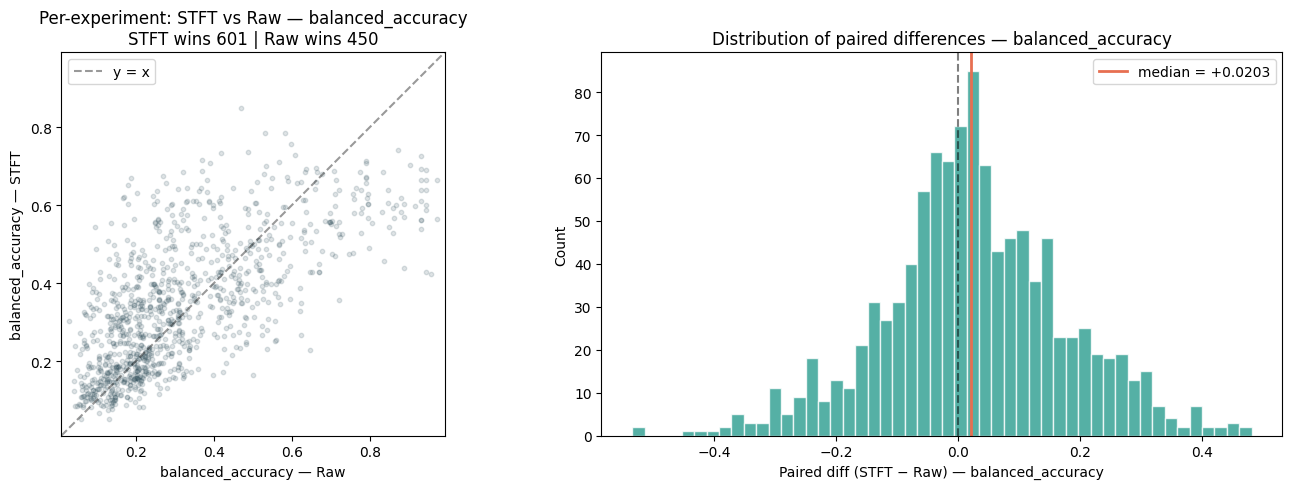

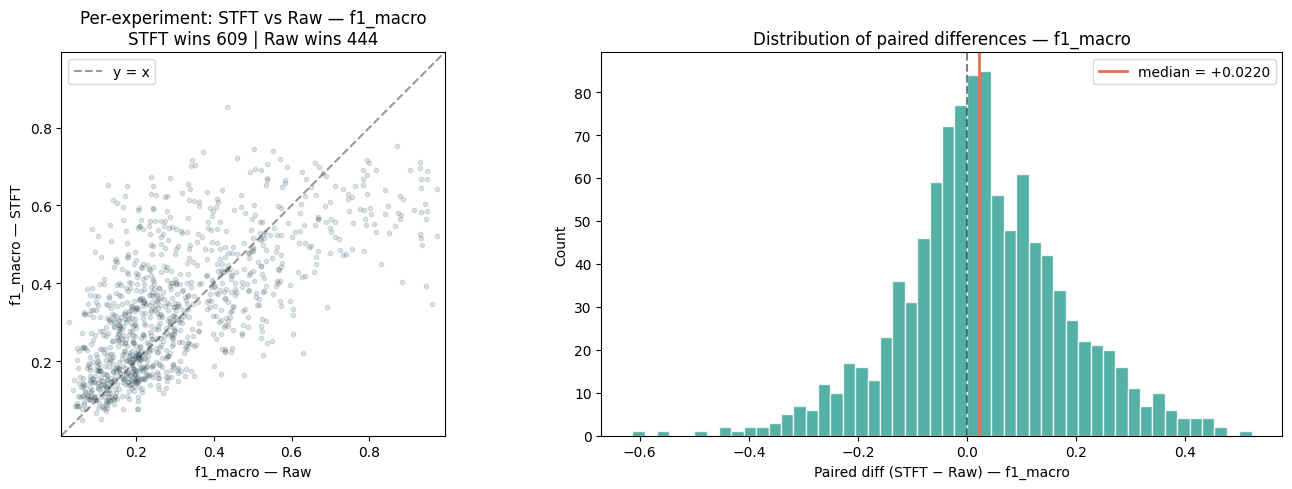

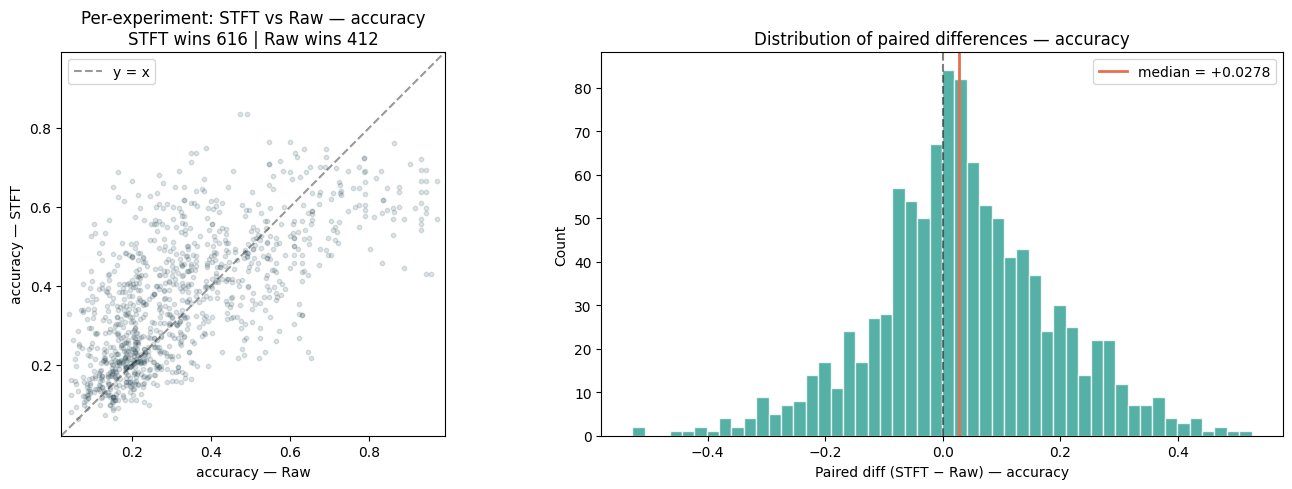

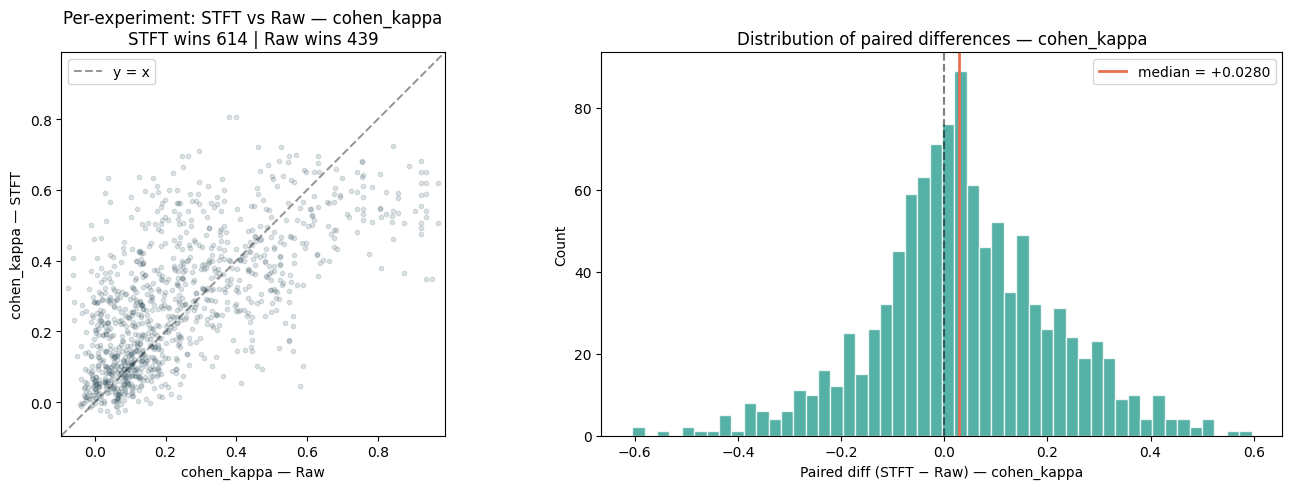

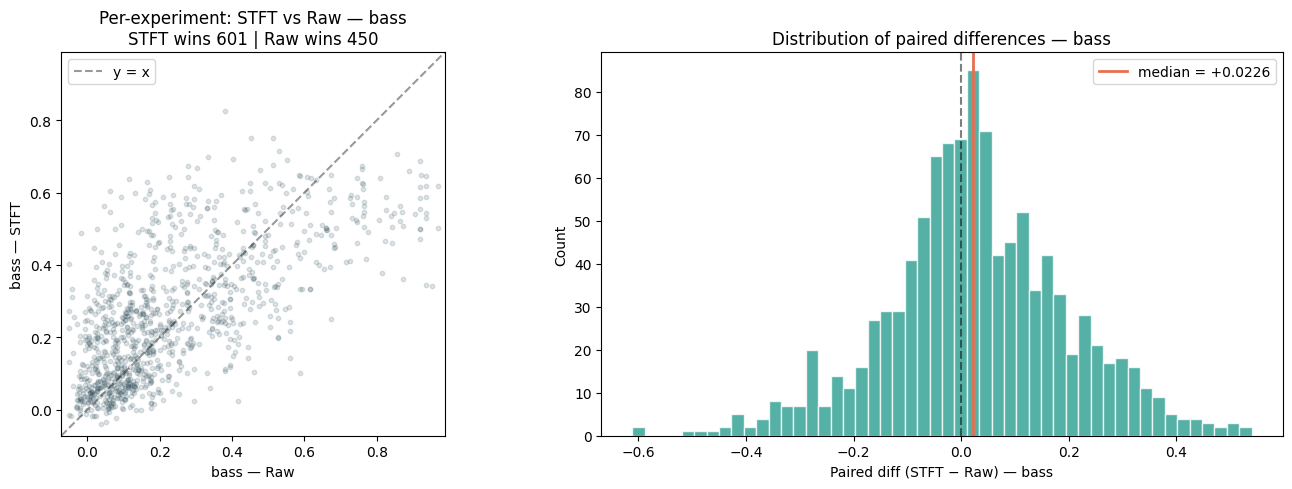

In [9]:
for metric in ALL_METRICS:
    stft_v = paired_stft.loc[common_idx, metric].values
    raw_v = paired_raw.loc[common_idx, metric].values
    diff = stft_v - raw_v

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Scatter
    ax = axes[0]
    ax.scatter(raw_v, stft_v, alpha=0.15, s=10, c="#264653")
    lims = [
        min(raw_v.min(), stft_v.min()) - 0.02,
        max(raw_v.max(), stft_v.max()) + 0.02,
    ]
    ax.plot(lims, lims, "k--", alpha=0.4, label="y = x")
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel(f"{metric} — Raw")
    ax.set_ylabel(f"{metric} — STFT")
    n_above = (diff > 0).sum()
    n_below = (diff < 0).sum()
    ax.set_title(f"Per-experiment: STFT vs Raw — {metric}\nSTFT wins {n_above} | Raw wins {n_below}")
    ax.legend()
    ax.set_aspect("equal")

    # Histogram of differences
    ax = axes[1]
    ax.hist(diff, bins=50, color="#2a9d8f", edgecolor="white", alpha=0.8)
    ax.axvline(0, color="k", ls="--", alpha=0.5)
    ax.axvline(np.median(diff), color="#e76f51", ls="-", lw=2, label=f"median = {np.median(diff):+.4f}")
    ax.set_xlabel(f"Paired diff (STFT − Raw) — {metric}")
    ax.set_ylabel("Count")
    ax.set_title(f"Distribution of paired differences — {metric}")
    ax.legend()

    plt.tight_layout()
    plt.show()

### 3.1  Paired comparison for no-bandpass baselines

Compare STFT vs Raw when no bandpass filtering is applied (one pair per recording).

In [10]:
bl_stft = baseline_all[baseline_all["stft"] == True].set_index("recording_id")
bl_raw = baseline_all[baseline_all["stft"] == False].set_index("recording_id")
bl_common = bl_stft.index.intersection(bl_raw.index)

print(f"Paired baseline recordings: {len(bl_common)}\n")

for metric in ALL_METRICS:
    s = bl_stft.loc[bl_common, metric].values
    r = bl_raw.loc[bl_common, metric].values
    d = s - r

    stat, p = wilcoxon(s, r, alternative="two-sided")

    print(f"--- {metric} (no bandpass) ---")
    print(f"  STFT wins: {(d > 0).sum()}  |  Raw wins: {(d < 0).sum()}")
    print(f"  Median diff: {np.median(d):+.4f}   p = {p:.4e}")
    print()

Paired baseline recordings: 39

--- balanced_accuracy (no bandpass) ---
  STFT wins: 15  |  Raw wins: 24
  Median diff: -0.0536   p = 1.2750e-01

--- f1_macro (no bandpass) ---
  STFT wins: 16  |  Raw wins: 23
  Median diff: -0.0491   p = 1.3846e-01

--- accuracy (no bandpass) ---
  STFT wins: 16  |  Raw wins: 22
  Median diff: -0.0417   p = 4.1257e-01

--- cohen_kappa (no bandpass) ---
  STFT wins: 15  |  Raw wins: 24
  Median diff: -0.0476   p = 3.0870e-01

--- bass (no bandpass) ---
  STFT wins: 15  |  Raw wins: 24
  Median diff: -0.0591   p = 1.3107e-01



## 4  Stratified Analysis: Awake vs Anesthetized

Repeat the paired comparison separately for awake and anesthetized
recordings, since anesthesia fundamentally alters neural activity.

In [11]:
for stratum_name, is_anest in [("Awake", False), ("Anesthetized", True)]:
    rec_ids = df.loc[df["anesthetized"] == is_anest, "recording_id"].unique()
    print(f"\n{'='*60}")
    print(f"  STRATUM: {stratum_name} ({len(rec_ids)} recordings)")
    print(f"{'='*60}")

    sub = all_conditions[all_conditions["recording_id"].isin(rec_ids)]
    idx_best_stratum = sub.groupby("recording_id")[METRIC].idxmax()
    best_stratum = sub.loc[idx_best_stratum]

    for metric in ALL_METRICS:
        vals = best_stratum[metric]
        print(f"  Best {metric}:  mean={vals.mean():.4f}  median={vals.median():.4f}  std={vals.std():.4f}")

    print(f"\n  Winning configs:")
    for label, count in best_stratum["config_label"].value_counts().items():
        print(f"    {label}: {count}")

    # Paired STFT vs Raw within this stratum
    s_sweep = sweep_all[sweep_all["recording_id"].isin(rec_ids)]
    s_stft = s_sweep[s_sweep["stft"] == True].set_index(IDX_COLS)
    s_raw = s_sweep[s_sweep["stft"] == False].set_index(IDX_COLS)
    s_common = s_stft.index.intersection(s_raw.index)

    if len(s_common) > 10:
        print(f"\n  Paired STFT vs Raw ({len(s_common)} pairs):")
        for metric in ALL_METRICS:
            sv = s_stft.loc[s_common, metric].values
            rv = s_raw.loc[s_common, metric].values
            d = sv - rv
            try:
                _, p = wilcoxon(sv, rv, alternative="two-sided")
            except ValueError:
                p = float("nan")
            print(f"    {metric}: median_diff={np.median(d):+.4f}  p={p:.4e}  STFT_wins={int((d > 0).sum())} Raw_wins={int((d < 0).sum())}")


  STRATUM: Awake (33 recordings)
  Best balanced_accuracy:  mean=0.5164  median=0.4692  std=0.2190
  Best f1_macro:  mean=0.5088  median=0.4747  std=0.2185
  Best accuracy:  mean=0.5282  median=0.4970  std=0.2118
  Best cohen_kappa:  mean=0.4637  median=0.4274  std=0.2373
  Best bass:  mean=0.4592  median=0.4073  std=0.2399

  Winning configs:
    Raw (no BP): 10
    STFT (no BP): 3
    STFT [13–500 Hz]: 2
    STFT [1–500 Hz]: 2
    STFT [30–500 Hz]: 2
    Raw [1–30 Hz]: 2
    Raw [1–150 Hz]: 2
    STFT [8–500 Hz]: 1
    STFT [4–300 Hz]: 1
    STFT [13–300 Hz]: 1
    Raw [4–500 Hz]: 1
    STFT [1–30 Hz]: 1
    Raw [4–30 Hz]: 1
    STFT [30–300 Hz]: 1
    Raw [1–500 Hz]: 1
    Raw [30–300 Hz]: 1
    STFT [4–150 Hz]: 1

  Paired STFT vs Raw (891 pairs):
    balanced_accuracy: median_diff=+0.0203  p=1.8351e-07  STFT_wins=515 Raw_wins=374
    f1_macro: median_diff=+0.0231  p=2.1298e-09  STFT_wins=523 Raw_wins=368
    accuracy: median_diff=+0.0278  p=5.9966e-12  STFT_wins=526 Raw_wins=341


## 5  Sweep Heatmaps

One heatmap per STFT mode showing mean `balanced_accuracy` across
recordings, plus a difference heatmap (STFT − Raw).

In [12]:
GROUP_COLS = ["lowcut", "highcut", "stft"]


def _aggregate(raw_df, group_cols, metrics):
    agg = raw_df.groupby(group_cols)[metrics].agg(["mean", "std"])
    out = raw_df[group_cols].drop_duplicates().reset_index(drop=True)
    agg = agg.reset_index(drop=True)
    for m in metrics:
        out[f"{m}_mean"] = agg[(m, "mean")].values
        out[f"{m}_std"] = agg[(m, "std")].values
        out[m] = out[f"{m}_mean"]
    return out


sweep_agg = _aggregate(sweep_all, GROUP_COLS, ALL_METRICS)

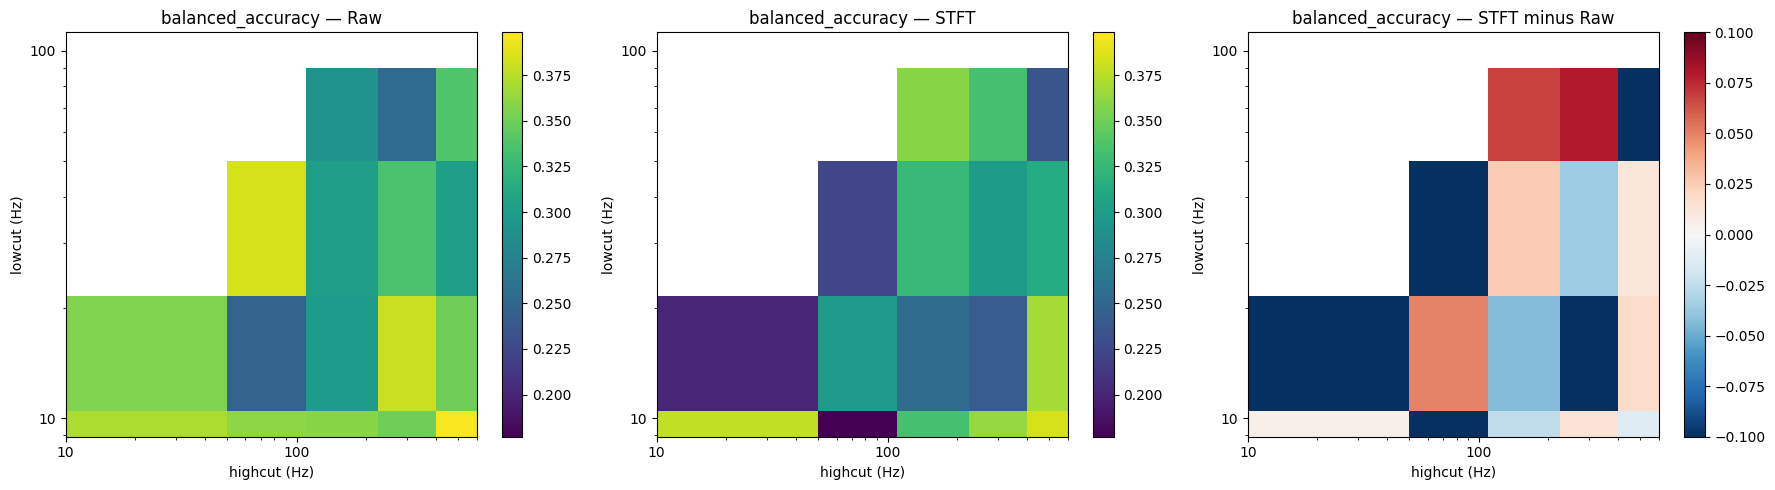

In [13]:
def plot_heatmap(df_mode, metric, ax, title, vmin=None, vmax=None, cmap="viridis"):
    pivot = df_mode.pivot_table(
        index="lowcut", columns="highcut", values=metric, aggfunc="mean"
    )
    lowcuts = pivot.index.values
    highcuts = pivot.columns.values

    im = ax.pcolormesh(
        highcuts, lowcuts, pivot.values,
        shading="nearest", cmap=cmap, vmin=vmin, vmax=vmax,
    )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("highcut (Hz)")
    ax.set_ylabel("lowcut (Hz)")
    ax.set_title(title)
    ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
    return im


stft_modes = sorted(sweep_agg["stft"].unique())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

vmin = sweep_agg[METRIC].min()
vmax = sweep_agg[METRIC].max()

sweep_stft_agg = sweep_agg[sweep_agg["stft"] == True].set_index(["lowcut", "highcut"])
sweep_raw_agg = sweep_agg[sweep_agg["stft"] == False].set_index(["lowcut", "highcut"])

for j, (stft_val, tag) in enumerate([(False, "Raw"), (True, "STFT")]):
    df_mode = sweep_agg[sweep_agg["stft"] == stft_val]
    im = plot_heatmap(df_mode, METRIC, axes[j], title=f"{METRIC} — {tag}", vmin=vmin, vmax=vmax)
    fig.colorbar(im, ax=axes[j])

# Difference heatmap
common_agg_idx = sweep_stft_agg.index.intersection(sweep_raw_agg.index)
diff_df = sweep_stft_agg.loc[common_agg_idx, [METRIC]].copy()
diff_df[METRIC] = sweep_stft_agg.loc[common_agg_idx, METRIC].values - sweep_raw_agg.loc[common_agg_idx, METRIC].values
diff_df = diff_df.reset_index()

pivot_d = diff_df.pivot_table(index="lowcut", columns="highcut", values=METRIC)
abs_max = max(abs(pivot_d.values.min()), abs(pivot_d.values.max()), 1e-6)
im = axes[2].pcolormesh(
    pivot_d.columns.values, pivot_d.index.values, pivot_d.values,
    shading="nearest", cmap="RdBu_r", vmin=-abs_max, vmax=abs_max,
)
axes[2].set_xscale("log")
axes[2].set_yscale("log")
axes[2].set_xlabel("highcut (Hz)")
axes[2].set_ylabel("lowcut (Hz)")
axes[2].set_title(f"{METRIC} — STFT minus Raw")
axes[2].xaxis.set_major_formatter(mticker.ScalarFormatter())
axes[2].yaxis.set_major_formatter(mticker.ScalarFormatter())
fig.colorbar(im, ax=axes[2])

plt.tight_layout()
plt.show()

## 6  Summary Plot — Best Linear Baseline per Recording

For each recording, the best achievable `balanced_accuracy` across all
configurations (STFT / Raw × all bandpass settings + no bandpass). This
is the number a deep-learning approach must beat.

In [14]:
summary = best_per_recording[[
    "recording_id", "subject", "anesthetized", "hemisphere",
    "config_label", "stft",
] + ALL_METRICS].copy()

# Short label for plotting
summary["short_id"] = [
    rid.replace("_task-AcousStim_acq-", " ").replace("_desc-raw", "")
    for rid in summary["recording_id"]
]

summary = summary.sort_values("subject")
summary

,recording_id,subject,anesthetized,hemisphere,config_label,stft,balanced_accuracy,f1_macro,accuracy,cohen_kappa,bass,short_id
84,sub-01_ses-01_task-AcousStim_acq-LH_desc-raw,sub-01,False,LH,STFT [8–500 Hz],True,0.350420,0.351095,0.415205,0.296991,0.242157,sub-01_ses-01 LH
175,sub-01_ses-02_task-AcousStim_acq-LH_desc-raw,sub-01,False,LH,STFT [13–500 Hz],True,0.398255,0.385573,0.404444,0.359288,0.358138,sub-01_ses-02 LH
11,sub-02_ses-02_task-AcousStim_acq-RH_desc-raw,sub-02,False,RH,STFT (no BP),True,0.352965,0.332573,0.351648,0.308542,0.309829,sub-02_ses-02 RH
204,sub-02_ses-01_task-AcousStim_acq-LH_desc-raw,sub-02,False,LH,STFT [4–300 Hz],True,0.462862,0.474710,0.483333,0.372734,0.373339,sub-02_ses-01 LH
248,sub-02_ses-01_task-AcousStim_acq-RH_desc-raw,sub-02,False,RH,STFT [1–500 Hz],True,0.556465,0.539474,0.587719,0.502784,0.482542,sub-02_ses-01 RH
333,sub-02_ses-02_task-AcousStim_acq-LH_desc-raw,sub-02,False,LH,STFT [13–300 Hz],True,0.314685,0.312565,0.313187,0.267358,0.268998,sub-02_ses-02 LH
454,sub-03_ses-01_task-AcousStim_acq-RH_desc-raw,sub-03,False,RH,STFT [1–500 Hz],True,0.445096,0.436273,0.490683,0.403515,0.375733,sub-03_ses-01 RH
18,sub-03_ses-03_task-AcousStim_acq-RHanest_desc-raw,sub-03,True,RH,Raw (no BP),False,0.489234,0.485934,0.510695,0.470427,0.452751,sub-03_ses-03 RHanest
709,sub-03_ses-04_task-AcousStim_acq-RHanest_desc-raw,sub-03,True,RH,STFT [13–70 Hz],True,0.537778,0.529873,0.549180,0.485035,0.480000,sub-03_ses-04 RHanest
514,sub-03_ses-03_task-AcousStim_acq-LHanest_desc-raw,sub-03,True,LH,Raw [1–500 Hz],False,0.559515,0.536417,0.548128,0.511727,0.528052,sub-03_ses-03 LHanest


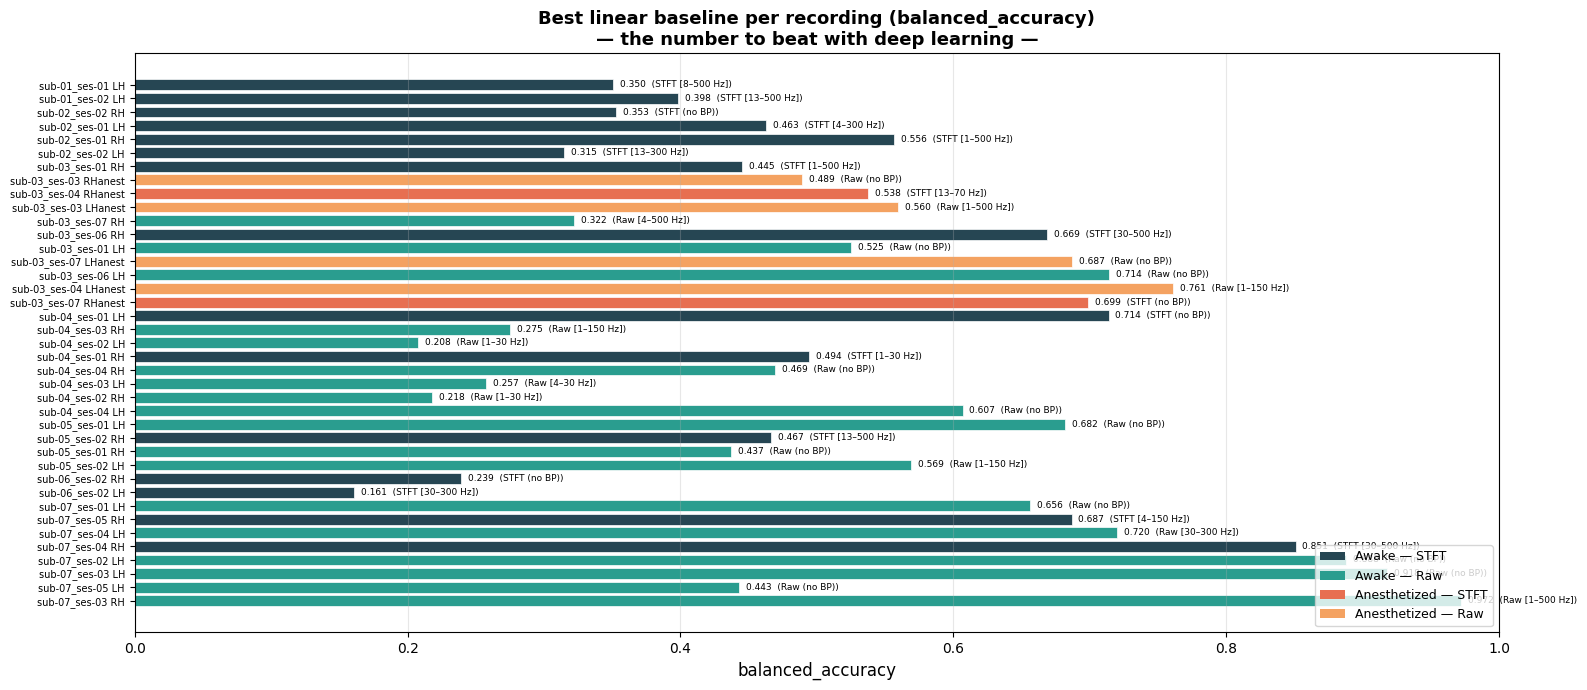

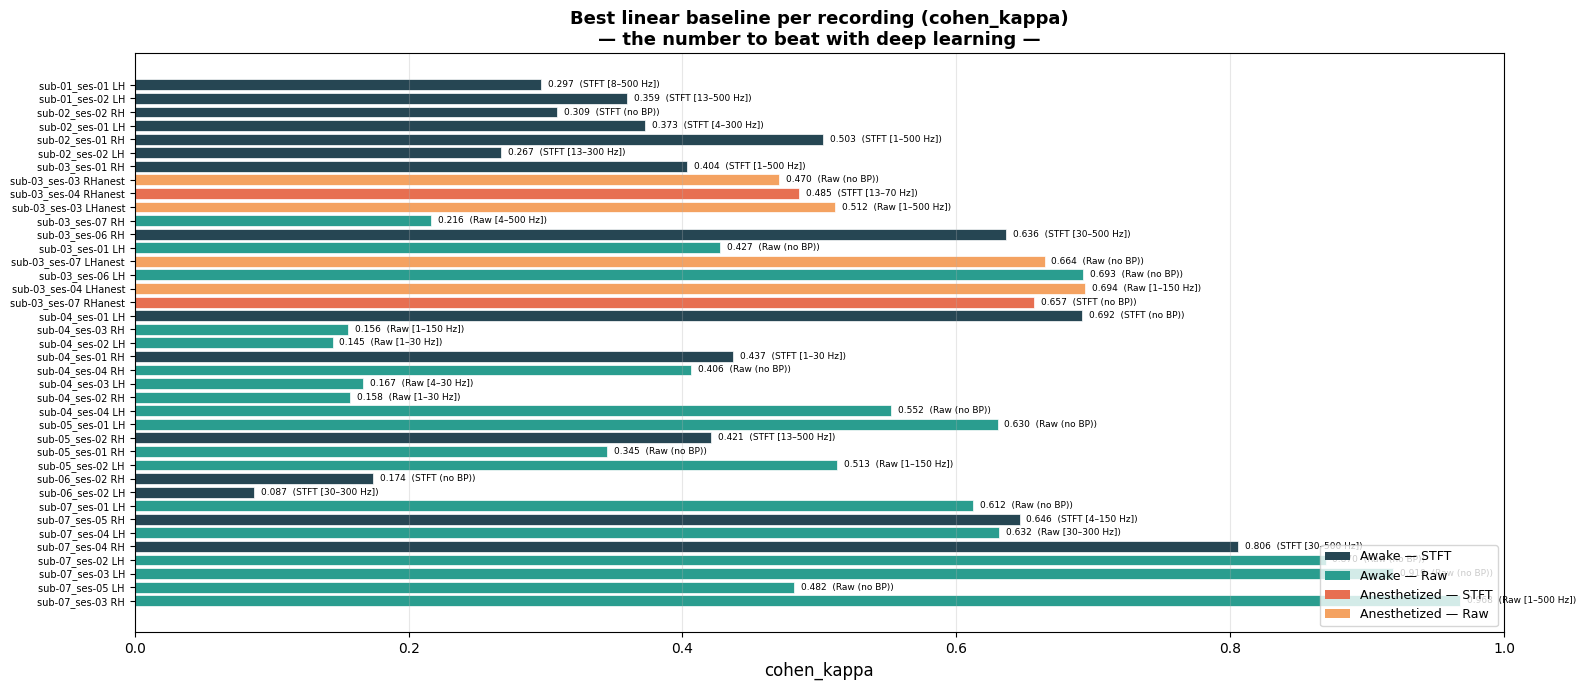

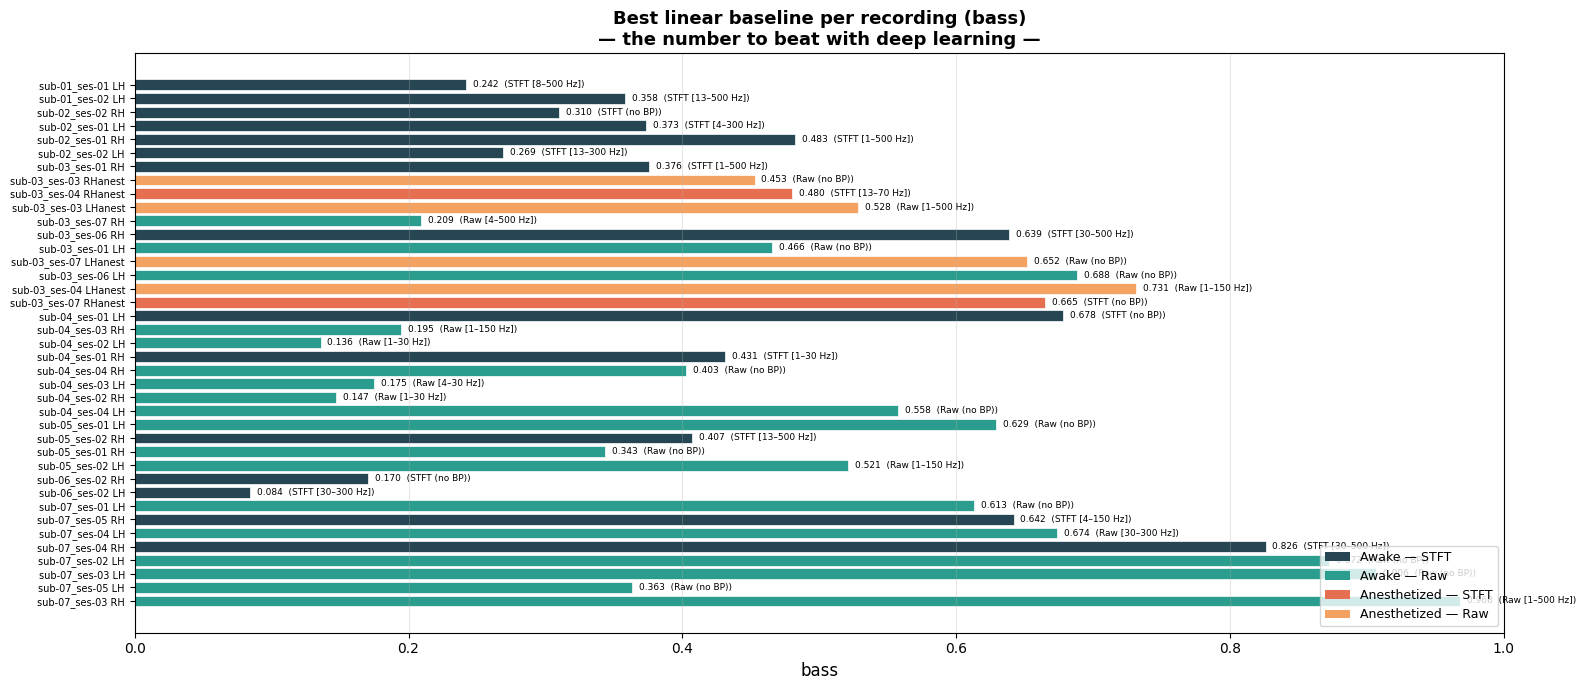

In [15]:
from matplotlib.patches import Patch

_LEGEND_ELEMENTS = [
    Patch(facecolor="#264653", label="Awake — STFT"),
    Patch(facecolor="#2a9d8f", label="Awake — Raw"),
    Patch(facecolor="#e76f51", label="Anesthetized — STFT"),
    Patch(facecolor="#f4a261", label="Anesthetized — Raw"),
]

def _recording_colors(summary_df):
    colors = []
    for _, row in summary_df.iterrows():
        if row["anesthetized"]:
            colors.append("#e76f51" if row["stft"] else "#f4a261")
        else:
            colors.append("#264653" if row["stft"] else "#2a9d8f")
    return colors


def plot_metric_bars(summary_df, metric, title_extra=""):
    has_data = metric in summary_df.columns and summary_df[metric].notna().any()
    if not has_data:
        print(f"Skipping {metric} — no data available.")
        return

    fig, ax = plt.subplots(figsize=(16, 7))
    colors = _recording_colors(summary_df)
    vals = summary_df[metric].values

    ax.barh(range(len(summary_df)), vals, color=colors, edgecolor="white", linewidth=0.5)
    ax.set_yticks(range(len(summary_df)))
    ax.set_yticklabels(summary_df["short_id"].values, fontsize=7)
    ax.set_xlabel(metric, fontsize=12)
    ax.set_title(
        f"Best linear baseline per recording ({metric}){title_extra}",
        fontsize=13, fontweight="bold",
    )

    for i, (_, row) in enumerate(summary_df.iterrows()):
        ax.text(
            row[metric] + 0.005, i,
            f"{row[metric]:.3f}  ({row['config_label']})",
            va="center", fontsize=6.5,
        )

    ax.legend(handles=_LEGEND_ELEMENTS, loc="lower right", fontsize=9)
    ax.invert_yaxis()

    lo = min(0, vals.min() - 0.05)
    hi = min(1.0, vals.max() + 0.12)
    ax.set_xlim(lo, hi)
    if lo < 0:
        ax.axvline(0, color="k", linewidth=0.8, alpha=0.4)
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_metric_bars(summary, METRIC, title_extra="\n— the number to beat with deep learning —")
plot_metric_bars(summary, "cohen_kappa", title_extra="\n— the number to beat with deep learning —")
plot_metric_bars(summary, "perm_zscore", title_extra="\n— permutation z-score (higher = more above chance) —")

In [16]:
for metric in [METRIC, "cohen_kappa", "perm_zscore"]:
    if metric not in summary.columns or summary[metric].isna().all():
        print(f"\n{metric}: no data available (re-run sweep with updated pipeline)\n")
        continue

    vals = summary[metric].dropna()
    print(f"Overall best linear baseline ({metric}):")
    print(f"  Mean:   {vals.mean():.4f}")
    print(f"  Median: {vals.median():.4f}")
    print(f"  Std:    {vals.std():.4f}")
    print(f"  Min:    {vals.min():.4f}")
    print(f"  Max:    {vals.max():.4f}")

    print(f"\n  Breakdown by condition:")
    for anest_val, anest_label in [(False, "Awake"), (True, "Anesthetized")]:
        sub = summary.loc[summary["anesthetized"] == anest_val, metric].dropna()
        if len(sub) > 0:
            print(f"    {anest_label} ({len(sub)} rec): mean={sub.mean():.4f}  median={sub.median():.4f}")
    print()

if "perm_pvalue" in summary.columns:
    for alpha in [0.05, 0.01, 0.001]:
        n_sig = (summary["perm_pvalue"] < alpha).sum()
        print(f"Recordings with perm p < {alpha}: {n_sig} / {len(summary)}")
    print()
    not_sig = summary[summary["perm_pvalue"] >= 0.05]
    if len(not_sig) > 0:
        print("Recordings NOT significant at alpha=0.05:")
        for _, row in not_sig.iterrows():
            print(f"  {row['short_id']:45s}  bal_acc={row['balanced_accuracy']:.3f}  p={row['perm_pvalue']:.4f}  z={row['perm_zscore']:.2f}")

Overall best linear baseline (balanced_accuracy):
  Mean:   0.5327
  Median: 0.5249
  Std:    0.2083
  Min:    0.1606
  Max:    0.9722

  Breakdown by condition:
    Awake (33 rec): mean=0.5164  median=0.4692
    Anesthetized (6 rec): mean=0.6221  median=0.6232

Overall best linear baseline (cohen_kappa):
  Mean:   0.4816
  Median: 0.4818
  Std:    0.2249
  Min:    0.0873
  Max:    0.9682

  Breakdown by condition:
    Awake (33 rec): mean=0.4637  median=0.4274
    Anesthetized (6 rec): mean=0.5804  median=0.5843

Overall best linear baseline (bass):
  Mean:   0.4785
  Median: 0.4656
  Std:    0.2286
  Min:    0.0843
  Max:    0.9683

  Breakdown by condition:
    Awake (33 rec): mean=0.4592  median=0.4073
    Anesthetized (6 rec): mean=0.5848  median=0.5900



In [17]:
# Export the per-recording best baseline for downstream use
export_path = CSV_PATH.parent / CSV_PATH.name.replace(".csv", "_best_per_recording.csv")
summary.to_csv(export_path, index=False)
print(f"Exported to {export_path}")

Exported to /home/mila/s/sobralm/auditorydecoding/results/frequency_decoding_sweep_raw_9205965_best_per_recording.csv
